# **Loss Given Default**

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.WARNING)

## **Feature Selection**

LGD measures how much of an exposure is actually lost once a default occurs. It is defined as:

$$\text{LGD} = 1 - \frac{\text{recoveries}}{\text{funded\_amnt}}$$

The dataset and feature set are the same as in the PD notebook — the same Lending Club Parquet file, the same origination-time variables. Two things are different:

- **Population:** LGD is only defined for loans that actually defaulted. Non-defaulted loans have no realised loss, so they are excluded from this dataset. This is not a modeling shortcut, it is the correct statistical approach. Training on non-defaults would contaminate the loss distribution with structural zeros that have nothing to do with recovery dynamics.
- **Target:** `recoveries` was dropped as a feature in the PD model because it is post-origination leakage. Here it is the *source* of the target variable. It is still not used as a feature.

## **Load & Filter to Defaults**

In [2]:
df_raw = pd.read_parquet('accepted.parquet', columns=[
    'loan_status',
    'funded_amnt',
    'annual_inc',
    'dti',
    'grade',
    'sub_grade',
    'int_rate',
    'emp_length',
    'home_ownership',
    'purpose',
    'term',
    'issue_d',
    'recoveries',
    'installment',
])

print(f'Full dataset: {len(df_raw):,} rows')

Full dataset: 2,260,701 rows


## **Custom Transformers**

Same transformers as the PD notebook. Copied here so this notebook is self-contained and the PKL produced at the end has no external dependencies.

### **Column Name Cleaner**

In [3]:
class ColumnNameCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.strip().str.lower().str.replace(' ', '_')
        return X

### **Loan Status Cleaner → Binary Target**

Same logic as the PD notebook, only loans with a definitive outcome are kept.

In [4]:
class LoanStatusCleaner(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.target_map = {'fully_paid': 0, 'charged_off': 1}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy = X_copy[X_copy['loan_status'].isin(self.target_map.keys())]
        X_copy['is_default'] = X_copy['loan_status'].map(self.target_map)
        return X_copy

### **Employment Length Transformer**

In [5]:
class EmpLengthTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy='mode'):
        self.strategy = strategy
        self.fill_value = None

    def fit(self, X, y=None):
        if self.strategy == 'mode':
            temp_col = pd.Series(X).str.extract('(\d+)').astype(float)
            self.fill_value = temp_col.mode()[0]
        else:
            self.fill_value = 0
        return self

    def transform(self, X):
        s = pd.Series(X).copy()
        s = s.replace('< 1 year', '0')
        s = s.str.extract('(\d+)', expand=False)
        s = s.astype(float)
        s = s.fillna(self.fill_value)
        return s.values.reshape(-1, 1)

### **Categorical Cleaner**

In [6]:
class CategoricalCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.select_dtypes(include=['object']).columns:
            X[col] = (
                X[col]
                .str.lower()
                .str.replace(' ', '_', regex=False)
                .str.replace('-', '_', regex=False)
                .str.lstrip('_')
            )
        return X

### **Term Transformer**

In [7]:
class TermTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X.iloc[:, 0]) if isinstance(X, pd.DataFrame) else pd.Series(X)
        return s.str.extract('(\d+)', expand=False).astype(float)

### **Grade / Sub-Grade Transformer**

In [8]:
class GradeTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        grades = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
        self.mapping = {
            f"{g}{i}": (count - 1) * 5 + i
            for count, g in enumerate(grades, 1)
            for i in range(1, 6)
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if 'sub_grade' in X.columns:
            X['sub_grade_num'] = X['sub_grade'].str.lower().map(self.mapping).fillna(0)
            X = X.drop(columns=[c for c in ['grade', 'sub_grade'] if c in X.columns])
        return X

### **Issue Date Transformer**

In [9]:
class IssueDateTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, column='issue_d', create_year=True, create_quarter=True, drop_original=False):
        self.column = column
        self.create_year = create_year
        self.create_quarter = create_quarter
        self.drop_original = drop_original

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.column] = pd.to_datetime(X[self.column], format='%b_%Y', errors='coerce')
        if self.create_year:
            X[f'{self.column}_year'] = X[self.column].dt.year
        if self.create_quarter:
            X[f'{self.column}_quarter'] = X[self.column].dt.to_period('Q')
        if self.drop_original:
            X = X.drop(columns=[self.column])
        return X

### **Winsorizer**

In [10]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        X_ = pd.DataFrame(X)
        for col in X_.columns:
            self.lower_bounds_[col] = X_[col].quantile(self.lower)
            self.upper_bounds_[col] = X_[col].quantile(self.upper)
        return self

    def transform(self, X):
        X_ = pd.DataFrame(X).copy()
        for col in X_.columns:
            X_[col] = X_[col].clip(
                lower=self.lower_bounds_.get(col),
                upper=self.upper_bounds_.get(col)
            )
        return X_.values

### **Feature Dropper**

In [11]:
class FeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        existing_cols = [col for col in self.columns_to_drop if col in X.columns]
        return X.drop(columns=existing_cols)

### **Loan Feature Engineer**

Same interaction terms as the PD model. All features are computable at origination time, so there is no leakage.

In [12]:
class LoanFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, create_log_income=True):
        self.create_log_income = create_log_income
        self._mean_rate_by_grade = None

    def fit(self, X, y=None):
        if 'sub_grade_num' in X.columns and 'int_rate' in X.columns:
            self._mean_rate_by_grade = X.groupby('sub_grade_num')['int_rate'].mean()
        return self

    def transform(self, X):
        X = X.copy()
        X['loan_to_income']  = X['funded_amnt'] / (X['annual_inc'] + 1)
        X['payment_burden']  = (X['installment'] * 12) / (X['annual_inc'] + 1)
        if self.create_log_income:
            X['log_annual_inc'] = np.log1p(X['annual_inc'])
        if 'purpose' in X.columns:
            X['is_risky_purpose'] = np.where(X['purpose'] == 'small_business', 1, 0)
        if 'dti' in X.columns and 'term' in X.columns:
            X['dti_x_term'] = X['dti'] * X['term']
        if self._mean_rate_by_grade is not None:
            expected_rate = X['sub_grade_num'].map(self._mean_rate_by_grade)
            X['int_rate_residual'] = X['int_rate'] - expected_rate
        if 'log_annual_inc' in X.columns and 'emp_length' in X.columns:
            X['inc_stability'] = X['log_annual_inc'] * X['emp_length']
        return X

## **Preprocessing & Target Engineering**

I run the same structural preprocessing steps as the PD notebook to get to a clean, consistent feature space. After that I create the LGD target and filter to defaults only.

The LGD target is clipped to `[0, 1]`. In rare cases, `recoveries` can marginally exceed `funded_amnt` due to late fees being recovered — capping at 1 prevents LGD from going negative, which has no economic meaning.

In [13]:
# Structural preprocessing (same pipeline as PD) 
df = df_raw.copy()
df = ColumnNameCleaner().transform(df)
df = CategoricalCleaner().transform(df)
df = LoanStatusCleaner().transform(df)

# Parse emp_length
_emp = EmpLengthTransformer()
_emp.fit(df['emp_length'])
df['emp_length'] = _emp.transform(df['emp_length'])

# Parse term
df['term'] = df['term'].str.extract('(\d+)', expand=False).astype(float)

# Sub-grade ordinal
df = GradeTransformer().transform(df)

# Issue date
df = IssueDateTransformer(drop_original=False).transform(df)

# LGD target
df['lgd'] = 1 - (df['recoveries'] / df['funded_amnt'].replace(0, np.nan))
df['lgd'] = df['lgd'].clip(0, 1)

# Filter to defaults only
df_defaults = df[df['is_default'] == 1].copy()

print(f'Defaulted loans: {len(df_defaults):,}')
print(f'LGD nulls: {df_defaults["lgd"].isnull().sum()}')

df_defaults['lgd'].describe().round(4)

Defaulted loans: 268,559
LGD nulls: 0


count    268559.0000
mean          0.9247
std           0.0947
min           0.0000
25%           0.8875
50%           0.9379
75%           1.0000
max           1.0000
Name: lgd, dtype: float64

## **EDA — LGD Distribution**

Unlike the PD notebook where EDA covered all features, here I only need to understand the target variable. The features themselves were already explored. What I need to confirm before choosing a model is the **shape of the LGD distribution**.

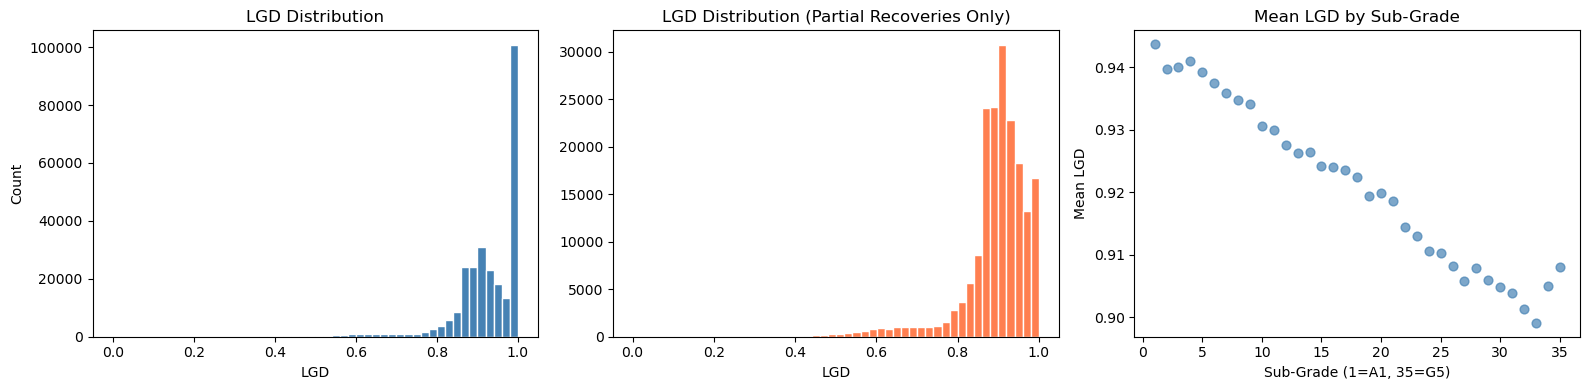

LGD = 1.0 (full loss)       :  83,875  (31.2%)
LGD = 0.0 (full recovery)   :     106  (0.0%)
0 < LGD < 1 (partial)       : 184,578  (68.7%)


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full distribution
axes[0].hist(df_defaults['lgd'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('LGD Distribution')
axes[0].set_xlabel('LGD')
axes[0].set_ylabel('Count')

# Zoom in on 0 < LGD < 1 (partial recoveries)
partial = df_defaults[(df_defaults['lgd'] > 0) & (df_defaults['lgd'] < 1)]['lgd']
axes[1].hist(partial, bins=50, color='coral', edgecolor='white')
axes[1].set_title('LGD Distribution (Partial Recoveries Only)')
axes[1].set_xlabel('LGD')

# LGD by sub_grade
lgd_by_grade = df_defaults.groupby('sub_grade_num')['lgd'].mean().reset_index()
axes[2].scatter(lgd_by_grade['sub_grade_num'], lgd_by_grade['lgd'],
                color='steelblue', alpha=0.7, s=40)
axes[2].set_title('Mean LGD by Sub-Grade')
axes[2].set_xlabel('Sub-Grade (1=A1, 35=G5)')
axes[2].set_ylabel('Mean LGD')

plt.tight_layout()
plt.show()

n_full_loss  = (df_defaults['lgd'] == 1).sum()
n_full_recov = (df_defaults['lgd'] == 0).sum()
n_partial    = ((df_defaults['lgd'] > 0) & (df_defaults['lgd'] < 1)).sum()
total        = len(df_defaults)

print(f"LGD = 1.0 (full loss)       : {n_full_loss:>7,}  ({n_full_loss/total:.1%})")
print(f"LGD = 0.0 (full recovery)   : {n_full_recov:>7,}  ({n_full_recov/total:.1%})")
print(f"0 < LGD < 1 (partial)       : {n_partial:>7,}  ({n_partial/total:.1%})")

The distribution confirms what's typical for unsecured consumer credit: the vast majority of defaulted loans result in a total loss (LGD = 1), with a smaller portion showing partial or full recovery.

This distribution is far from normal, and a standard regression assumes nothing about the target distribution, so a single XGBoost regressor is appropriate for a first model. A more advanced approach would use a **two-stage model**: first classify whether any recovery occurs at all, then regress on the recovery amount conditional on it being positive. That's a natural next iteration but out of scope here.

## **Feature Engineering**

In [15]:
fe = LoanFeatureEngineer(create_log_income=True)
df_defaults = fe.fit_transform(df_defaults)

ENGINEERED_NUMERIC = [
    'loan_to_income', 'payment_burden', 'log_annual_inc',
    'dti_x_term', 'int_rate_residual', 'inc_stability'
]

NUMERIC_FEATURES   = ['funded_amnt', 'annual_inc', 'dti', 'int_rate',
                       'emp_length', 'term', 'sub_grade_num']
ALL_NUMERIC        = NUMERIC_FEATURES + ENGINEERED_NUMERIC
CATEGORICAL_FEATURES = ['home_ownership', 'purpose']
TARGET             = 'lgd'

# Drop leakage and structural columns
# recoveries: used to create target, not a feature
# installment: r≈0.95 with funded_amnt, same as PD notebook
# is_default: constant (all 1s in this subset)
COLS_TO_DROP = ['recoveries', 'installment', 'issue_d',
                'loan_status', 'issue_d_quarter', 'is_default']

df_model = FeatureDropper(COLS_TO_DROP).fit_transform(df_defaults)
print(df_model.shape)
df_model.head(3)

(268559, 18)


,funded_amnt,annual_inc,dti,int_rate,emp_length,home_ownership,purpose,term,sub_grade_num,issue_d_year,lgd,loan_to_income,payment_burden,log_annual_inc,is_risky_purpose,dti_x_term,int_rate_residual,inc_stability
13,18000.0,150000.0,9.39,19.48,7.0,rent,debt_consolidation,60.0,22,2015,0.910061,0.119999,0.037736,11.918397,0,563.40,-0.991403,83.428781
25,4225.0,35000.0,15.22,14.85,5.0,rent,debt_consolidation,36.0,15,2015,0.912812,0.120711,0.050111,10.463132,0,547.92,-0.677019,52.315660
30,16000.0,65000.0,18.96,12.88,10.0,mortgage,small_business,36.0,12,2015,1.000000,0.246150,0.099355,11.082158,1,682.56,-0.489533,110.821579


## **Time-Based Train / Validation / Test Split**

Same cutoffs as the PD notebook: train on loans issued up to 2015, validate on 2016, test on 2017+. The split is applied to the defaulted-only subset, so the sizes here are much smaller than in the PD model.

In [16]:
train_mask = df_model['issue_d_year'] <= 2015
val_mask   = df_model['issue_d_year'] == 2016
test_mask  = df_model['issue_d_year'] >= 2017

X_train = df_model[train_mask].drop(columns=[TARGET, 'issue_d_year'])
y_train = df_model[train_mask][TARGET]

X_val   = df_model[val_mask].drop(columns=[TARGET, 'issue_d_year'])
y_val   = df_model[val_mask][TARGET]

X_test  = df_model[test_mask].drop(columns=[TARGET, 'issue_d_year'])
y_test  = df_model[test_mask][TARGET]

print(f'Train : {len(X_train):>7,} rows  (years ≤ 2015) | mean LGD: {y_train.mean():.4f}')
print(f'Val   : {len(X_val):>7,} rows  (year  = 2016) | mean LGD: {y_val.mean():.4f}')
print(f'Test  : {len(X_test):>7,} rows  (years ≥ 2017) | mean LGD: {y_test.mean():.4f}')

Train : 152,302 rows  (years ≤ 2015) | mean LGD: 0.9209
Val   :  68,242 rows  (year  = 2016) | mean LGD: 0.9228
Test  :  48,015 rows  (years ≥ 2017) | mean LGD: 0.9393


## **Preprocessing Pipeline**

The pipeline structure is the same as the PD notebook, with one difference: categorical features are encoded with **One-Hot Encoding** instead of WoE.

WoE encoding is defined relative to a binary target. For a regression problem like LGD there is no binary event, so WoE is not applicable. OHE is the straightforward alternative.

In [17]:
numeric_transformer = Pipeline(steps=[
    ('winsorizer', Winsorizer(lower=0.01, upper=0.99)),
    ('imputer',    SimpleImputer(strategy='median')),
    ('scaler',     StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    ALL_NUMERIC),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
], verbose_feature_names_out=False)

X_train_final = preprocessor.fit_transform(X_train)
X_val_final   = preprocessor.transform(X_val)
X_test_final  = preprocessor.transform(X_test)

print(f'Feature matrix shape — Train: {X_train_final.shape} | Val: {X_val_final.shape} | Test: {X_test_final.shape}')

Feature matrix shape — Train: (152302, 32) | Val: (68242, 32) | Test: (48015, 32)


## **Model Comparison**

I compare three regressors before tuning:

- **Ridge**: a penalised linear model. Establishes a baseline and also provides an interpretability reference, if the non-linear models don't clearly beat it, it's worth keeping things simple.
- **Random Forest**: ensemble of trees, handles non-linearity and feature interactions without much configuration.
- **XGBoost**: the same architecture that won the PD comparison. Gradient boosting tends to perform well on tabular data.

Evaluation metrics:
- **MAE** (Mean Absolute Error): average absolute deviation in LGD units. The most interpretable, an MAE of 0.10 means on average we're off by 10 percentage points.
- **RMSE**: penalises large errors more. Useful for detecting if the model has catastrophic misses on some cases.
- **R²**: fraction of LGD variance explained.
- **Mean Bias**: mean(predicted) − mean(actual). Tells us if the model is systematically over- or under-estimating LGD, which matters for provisioning.

In [18]:
def evaluate_regressor(model, X_tr, y_tr, X_v, y_v, name=''):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v).clip(0, 1)  # LGD is bounded
    return {
        'MAE':       mean_absolute_error(y_v, preds),
        'RMSE':      mean_squared_error(y_v, preds) ** 0.5,
        'R2':        r2_score(y_v, preds),
        'Mean Bias': preds.mean() - y_v.mean(),
    }


models = {
    'Ridge':         Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10,
                                           random_state=42, n_jobs=-1),
    'XGBoost':       XGBRegressor(objective='reg:squarederror', n_estimators=300,
                                   learning_rate=0.05, max_depth=4, subsample=0.8,
                                   colsample_bytree=0.8, tree_method='hist',
                                   random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    results[name] = evaluate_regressor(model, X_train_final, y_train,
                                        X_val_final, y_val, name)

comparison_df = pd.DataFrame(results).T.round(4)
display(comparison_df)

Training Ridge...
Training Random Forest...
Training XGBoost...


,MAE,RMSE,R2,Mean Bias
Ridge,0.0631,0.0968,0.0091,-0.0020
Random Forest,0.0638,0.0973,-0.0009,-0.0039
XGBoost,0.0634,0.0969,0.0064,-0.0026


* MAE and RMSE are the primary ranking metrics. Lower is better.
* R² for LGD models is typically modest — the LGD distribution is dominated by the spike at 1.0, which is hard to explain with origination features alone. A slightly positive R² already represents useful predictive signal.
* Mean Bias close to 0 is important for the EL calculation downstream.

## **Fine Tuning XGBoost**

Same Optuna approach as the PD notebook. I optimise **MAE** on the validation set (minimisation problem). Early stopping handles `n_estimators` automatically.

In [19]:
MAX_ROUNDS = 800
EARLY_STOP = 50
N_TRIALS   = 60


def objective(trial):
    params = {
        'max_depth':          trial.suggest_int('max_depth', 3, 7),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 20),
        'gamma':              trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha',  1e-4, 10.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'subsample':          trial.suggest_float('subsample',        0.60, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.50, 1.0),
        'colsample_bylevel':  trial.suggest_float('colsample_bylevel',0.50, 1.0),
        'learning_rate':      trial.suggest_float('learning_rate', 0.005, 0.20, log=True),
        'objective':          'reg:squarederror',
        'eval_metric':        'mae',
        'tree_method':        'hist',
        'n_jobs':             -1,
        'random_state':       42,
        'n_estimators':       MAX_ROUNDS,
    }

    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, 'validation_0-mae')

    model = XGBRegressor(
        **params,
        early_stopping_rounds = EARLY_STOP,
        callbacks             = [pruning_callback],
    )
    model.fit(
        X_train_final, y_train,
        eval_set = [(X_val_final, y_val)],
        verbose  = False,
    )

    preds = model.predict(X_val_final).clip(0, 1)
    return mean_absolute_error(y_val, preds)


study = optuna.create_study(
    direction  = 'minimize',
    sampler    = optuna.samplers.TPESampler(seed=42),
    pruner     = optuna.pruners.MedianPruner(n_warmup_steps=10),
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/60 [00:00<?, ?it/s]

In [20]:
print(f'Best MAE (validation): {study.best_value:.4f}')
print('Best parameters:')
for k, v in study.best_params.items():
    print(f'  {k:<25} {v}')

Best MAE (validation): 0.0631
Best parameters:
  max_depth                 7
  min_child_weight          15
  gamma                     0.15009067381679922
  reg_alpha                 1.0417560182694268
  reg_lambda                0.00018013709819695355
  subsample                 0.908889233021975
  colsample_bytree          0.7793152603737501
  colsample_bylevel         0.5824751893985639
  learning_rate             0.16466318697850527


### **Retraining the Final Model**

In [21]:
best_lgd_model = XGBRegressor(
    **study.best_params,
    objective             = 'reg:squarederror',
    eval_metric           = 'mae',
    tree_method           = 'hist',
    n_jobs                = -1,
    random_state          = 42,
    n_estimators          = MAX_ROUNDS,
    early_stopping_rounds = EARLY_STOP,
)

best_lgd_model.fit(
    X_train_final, y_train,
    eval_set = [(X_val_final, y_val)],
    verbose  = 50,
)

print(f'\nModel stopped at tree #{best_lgd_model.best_iteration}')

[0]	validation_0-mae:0.06392
[50]	validation_0-mae:0.06312
[80]	validation_0-mae:0.06312

Model stopped at tree #30


## **Final Evaluation on the Test Set**

The test set (2017+) hasn't been touched. These numbers are the honest estimate of out-of-sample performance.

In [22]:
y_test_pred = best_lgd_model.predict(X_test_final).clip(0, 1)

test_metrics = {
    'MAE':       mean_absolute_error(y_test, y_test_pred),
    'RMSE':      mean_squared_error(y_test, y_test_pred) ** 0.5,
    'R2':        r2_score(y_test, y_test_pred),
    'Mean Bias': y_test_pred.mean() - y_test.mean(),
}

pd.DataFrame(test_metrics, index=['XGBoost LGD (tuned)']).round(4)

,MAE,RMSE,R2,Mean Bias
XGBoost LGD (tuned),0.0678,0.0842,-0.0411,-0.0182


### **Predicted vs. Actual LGD**

A scatter of predicted vs. actual LGD shows whether the model is systematically wrong in any region, and also makes the inherent difficulty of the task visible — the spike at LGD = 1 is very hard to differentiate with origination features alone.

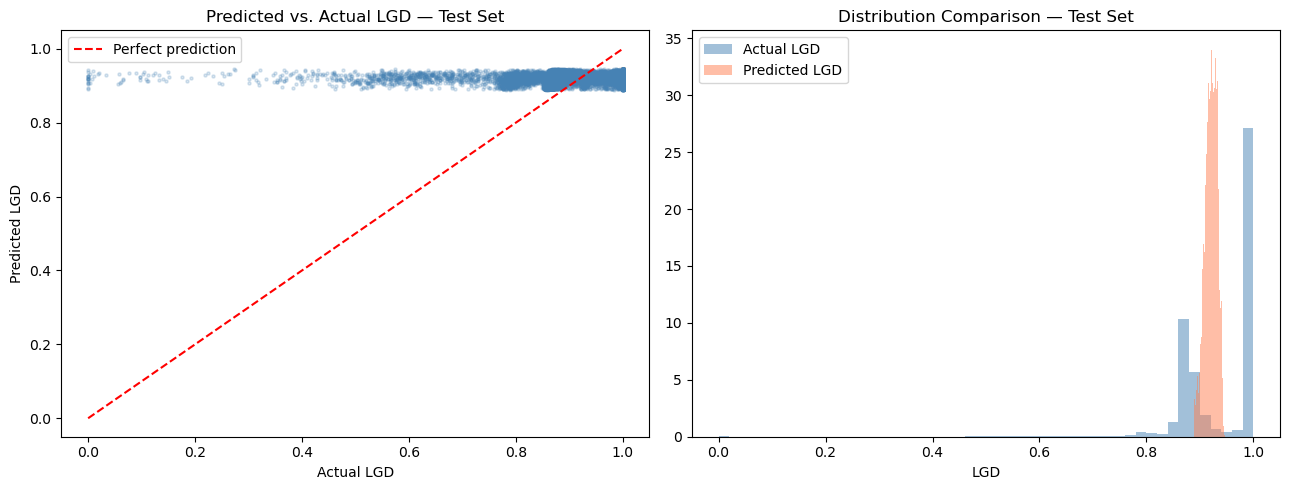

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter predicted vs actual
axes[0].scatter(y_test, y_test_pred, alpha=0.2, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual LGD')
axes[0].set_ylabel('Predicted LGD')
axes[0].set_title('Predicted vs. Actual LGD — Test Set')
axes[0].legend()

# Distribution overlay
axes[1].hist(y_test,      bins=50, alpha=0.5, color='steelblue', label='Actual LGD',    density=True)
axes[1].hist(y_test_pred, bins=50, alpha=0.5, color='coral',     label='Predicted LGD', density=True)
axes[1].set_xlabel('LGD')
axes[1].set_title('Distribution Comparison — Test Set')
axes[1].legend()

plt.tight_layout()
plt.show()

### **Mean LGD by Decile**

This is the most practical validation for a provisioning use case. Loans are sorted by predicted LGD, split into 10 deciles, and the mean predicted vs. mean actual LGD is compared within each bucket. A well-calibrated model should track the actual mean closely across all deciles.

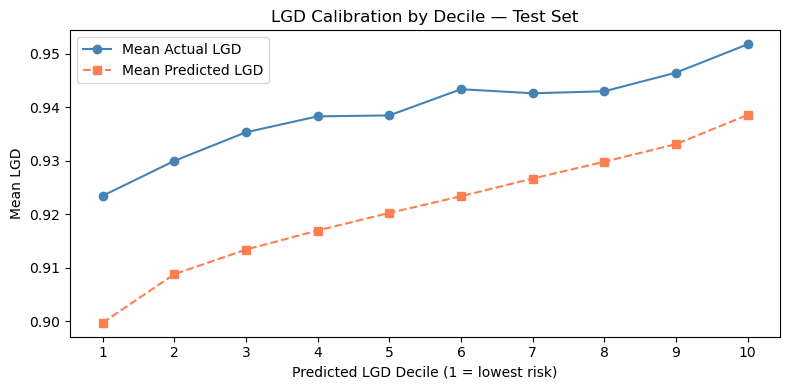

,decile,mean_actual,mean_predicted,count
0,1,0.9234,0.8997,4812
1,2,0.9300,0.9088,4801
2,3,0.9353,0.9134,4792
3,4,0.9383,0.9170,4801
4,5,0.9385,0.9202,4802
5,6,0.9434,0.9234,4802
6,7,0.9426,0.9267,4818
7,8,0.9430,0.9298,4823
8,9,0.9465,0.9331,4764
9,10,0.9518,0.9386,4800


In [24]:
decile_df = pd.DataFrame({'actual': y_test.values, 'predicted': y_test_pred})
decile_df['decile'] = pd.qcut(decile_df['predicted'], q=10, labels=False) + 1

decile_summary = decile_df.groupby('decile').agg(
    mean_actual    = ('actual',    'mean'),
    mean_predicted = ('predicted', 'mean'),
    count          = ('actual',    'count'),
).reset_index()

plt.figure(figsize=(8, 4))
plt.plot(decile_summary['decile'], decile_summary['mean_actual'],
         'o-', color='steelblue', label='Mean Actual LGD')
plt.plot(decile_summary['decile'], decile_summary['mean_predicted'],
         's--', color='coral', label='Mean Predicted LGD')
plt.xticks(decile_summary['decile'])
plt.xlabel('Predicted LGD Decile (1 = lowest risk)')
plt.ylabel('Mean LGD')
plt.title('LGD Calibration by Decile — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

display(decile_summary.round(4))

### **Feature Importance**

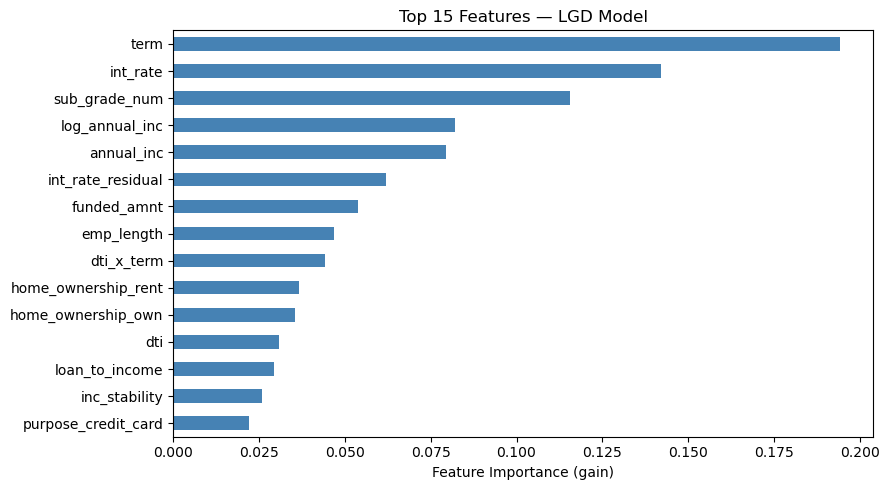

In [25]:
feature_names = (
    ALL_NUMERIC +
    preprocessor.named_transformers_['cat']['ohe']
               .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
)

feat_imp = pd.Series(best_lgd_model.feature_importances_, index=feature_names)
feat_imp.nlargest(15).sort_values().plot(
    kind='barh', figsize=(9, 5), color='steelblue'
)
plt.title('Top 15 Features — LGD Model')
plt.xlabel('Feature Importance (gain)')
plt.tight_layout()
plt.show()

## **Export**

I export two separate PKL files:
- `lgd_preprocessor.pkl`: the fitted `ColumnTransformer`. Takes raw feature columns and returns the numeric matrix.
- `lgd_model.pkl`: the fitted `XGBRegressor`.

Keeping them separate makes it easier to swap out either component independently, and mirrors the structure that will be used in the EL calculation and dashboard.

In [26]:
joblib.dump(preprocessor,    'lgd_preprocessor.pkl')
joblib.dump(best_lgd_model,  'lgd_model.pkl')

print('Exported: lgd_preprocessor.pkl')
print('Exported: lgd_model.pkl')

# Smoke test: reload and predict on one row
_pre   = joblib.load('lgd_preprocessor.pkl')
_model = joblib.load('lgd_model.pkl')
_X     = _pre.transform(X_test.iloc[:1])
_pred  = _model.predict(_X).clip(0, 1)
print(f'\nSmoke test LGD prediction: {_pred[0]:.4f}')

Exported: lgd_preprocessor.pkl
Exported: lgd_model.pkl

Smoke test LGD prediction: 0.9197


### **Future Improvements**

Two-Stage Model (Hurdle Model):

    Stage 1 (Classification): A logistic regression or XGBoost Classifier to predict if any recovery will happen at all (Is Recovery > 0?). Here, you would have a threshold.

    Stage 2 (Regression): If Stage 1 predicts a recovery, use your XGBRegressor to predict how much the LGD will be.